# 🔒 Notebook 3 — Collar
> Monthly Zero-Cost Collar  |  30 DTE  |  Put Δ≈−0.25  |  Call Δ≈+0.25

---

## 1. Theory

The collar combines a **protective put** (hedging) and a **short call** (financing):

$$\text{P\&L} = \begin{cases} K_p - S_0 - (p-c) & S_T < K_p \\ S_T - S_0 - (p-c) & K_p \leq S_T \leq K_c \\ K_c - S_0 - (p-c) & S_T > K_c \end{cases}$$

**Zero-cost collar**: select $K_c$ such that $c \approx p$ → no net premium.

**Greeks:** reduced Δ, short Γ, near-zero ν (long put ≈ short call in vega).

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.plotting    import *
from src.metrics     import compute_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


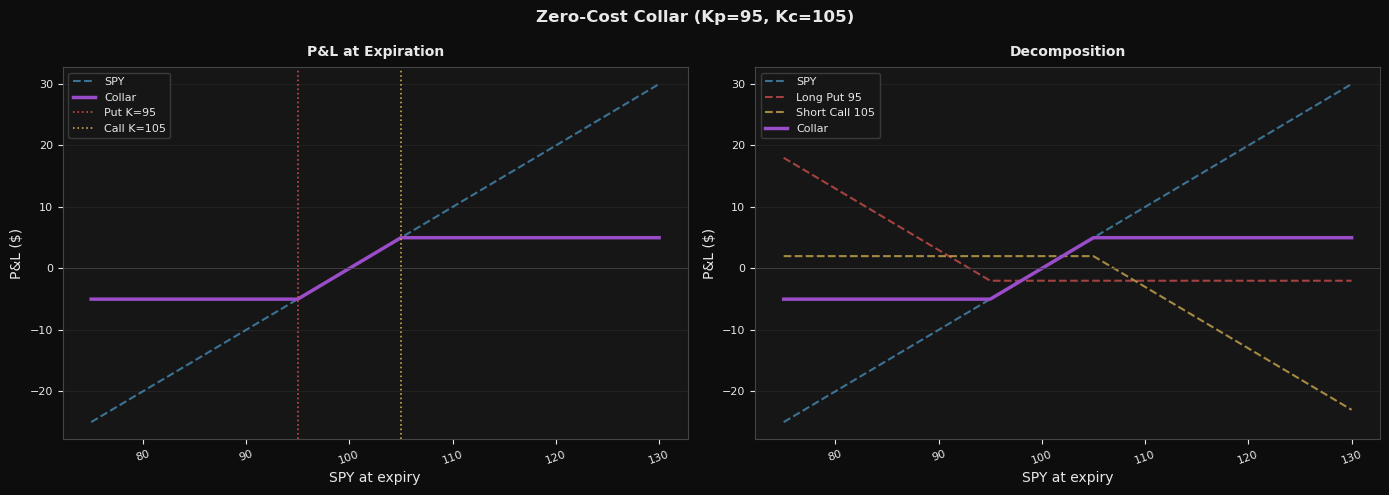

In [3]:
fig, axes = plt.subplots(1,2,figsize=(14,5),facecolor=BG)
S0,Kp,p,Kc,c = 100,95,2.0,105,2.0
ST = np.linspace(75,130,500)
pnl_spy = ST-S0
pnl_collar = pnl_spy+np.maximum(Kp-ST,0)-p+(c-np.maximum(ST-Kc,0))
axes[0].plot(ST,pnl_spy,   color=BLUE,  lw=1.5,ls='--',label='SPY',alpha=0.7)
axes[0].plot(ST,pnl_collar,color=PURPLE,lw=2.5,label='Collar')
axes[0].axvline(Kp,color=RED, lw=1.2,ls=':',label=f'Put K={Kp}')
axes[0].axvline(Kc,color=GOLD,lw=1.2,ls=':',label=f'Call K={Kc}')
style_ax(axes[0],'P&L at Expiration'); legend(axes[0])
axes[0].set_xlabel('SPY at expiry'); axes[0].set_ylabel('P&L ($)')
axes[1].plot(ST,pnl_spy,color=BLUE,lw=1.5,ls='--',label='SPY',alpha=0.7)
axes[1].plot(ST,np.maximum(Kp-ST,0)-p,color=RED, lw=1.5,ls='--',label=f'Long Put {Kp}',alpha=0.8)
axes[1].plot(ST,c-np.maximum(ST-Kc,0),color=GOLD,lw=1.5,ls='--',label=f'Short Call {Kc}',alpha=0.8)
axes[1].plot(ST,pnl_collar,color=PURPLE,lw=2.5,label='Collar')
style_ax(axes[1],'Decomposition'); legend(axes[1])
axes[1].set_xlabel('SPY at expiry'); axes[1].set_ylabel('P&L ($)')
fig.suptitle(f'Zero-Cost Collar (Kp={Kp}, Kc={Kc})',color=WHITE,fontsize=12,fontweight='bold')
fig.patch.set_facecolor(BG); plt.tight_layout(); plt.show()

## 2. Strategy Construction

$$V_t = S_t + \text{Cash}_t + \text{Put}_{\text{MTM},t} - \text{Call}_{\text{MTM},t}$$

**Cash at roll**: `Cash += C_mid - P_mid` (net, often ≈ 0)

In [8]:

#DATA_PATH = '../data/spy_simulated_2020_2022.csv'
# Uncomment to use real data:
DATA_PATH = '../data/spy_2020_2022.csv'

df = load_data(DATA_PATH)
print('Data loaded:', df.shape)

✅  Loaded: ../data/spy_2020_2022.csv
    Rows            : 3,589,079
    Period          : 2020-01-02 → 2022-12-30
    Trading days    : 758
    Unique strikes  : 641
    Unique expiries : 514
Data loaded: (3589079, 35)


In [9]:
from src.strategy_collar import build_collar
col = build_collar(df, target_dte=30, put_delta=-0.25, call_delta=0.25)
col[['spy_price','index_level','spy_bnh','put_strike','call_strike','net_cost']].tail(10)

✅  Collar index built
    Days      : 758
    Rolls     : 37
    Avg put IV: 25.07%
    Avg net cost per roll: 1.482


,spy_price,index_level,spy_bnh,put_strike,call_strike,net_cost
date,,,,,,
2022-12-19,380.02,114.141041,116.976021,387.0,416.0,1.100
2022-12-20,380.49,114.170283,117.120694,387.0,416.0,1.100
2022-12-21,386.21,114.542740,118.881399,387.0,416.0,1.100
2022-12-22,380.72,114.081017,117.191492,387.0,416.0,1.100
2022-12-23,382.88,113.991751,117.856373,369.0,398.0,0.785
2022-12-26,382.91,114.007141,117.865608,369.0,398.0,0.785
2022-12-27,381.38,113.679318,117.394650,369.0,398.0,0.785
2022-12-28,376.71,112.877459,115.957152,369.0,398.0,0.785
2022-12-29,383.33,114.024071,117.994890,369.0,398.0,0.785


## 3. Performance Dashboard

  Chart saved → ../outputs/chart_collar.png


/Users/kingced/Desktop/PersonalTraining/Options strat/Option Index Strat /spy_options_repo/src/plotting.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


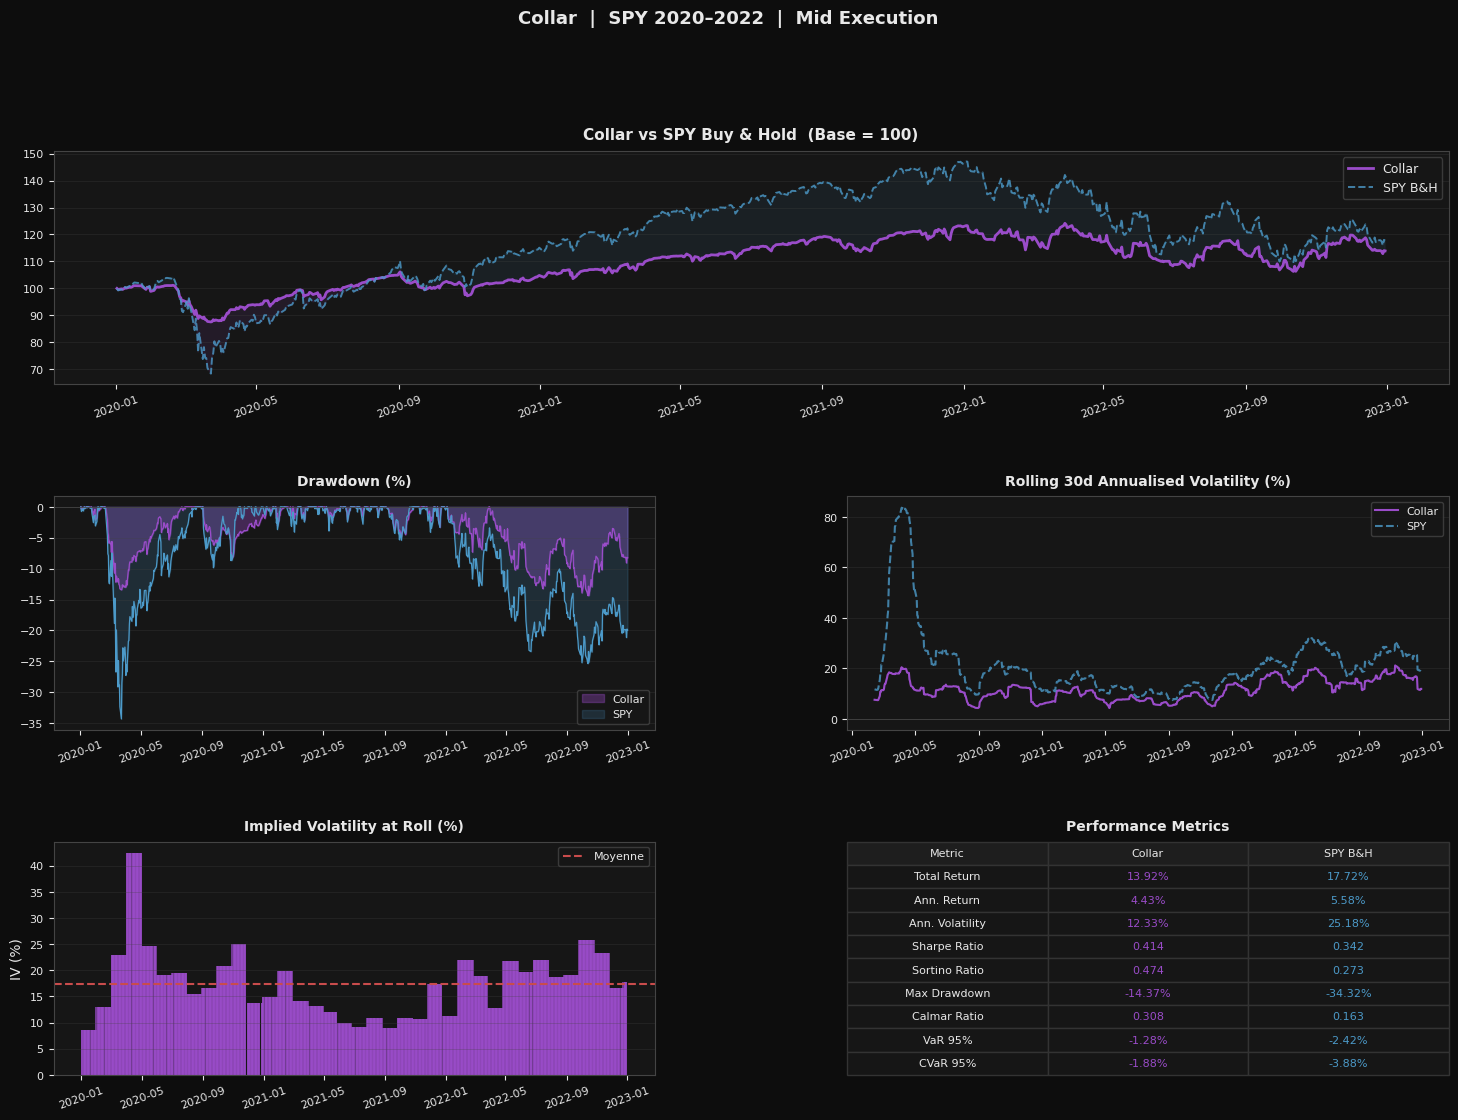

In [10]:
from src.plotting import plot_strategy_dashboard
plot_strategy_dashboard(col, 'Collar', PURPLE,
                        save_path='../outputs/chart_collar.png')

## 4. Metrics

In [7]:
m = compute_metrics(col)
for k,v in m.items():
    if isinstance(v,float): print(f'  {k:<25} {v:.4f}')

  Total Return              0.1556
  Ann. Return               0.0478
  Ann. Volatility           0.4993
  Skewness                  10.9965
  Kurtosis                  240.5323
  Max Drawdown              -0.4996
  Avg DD Duration           62.7500
  Sharpe Ratio              0.3052
  Sortino Ratio             0.1426
  Calmar Ratio              0.0956
  Omega Ratio               1.1174
  VaR 95%                   -0.0211
  CVaR 95%                  -0.0608
